<a href="https://colab.research.google.com/github/MidhulaMS/EV-Population-Prediction/blob/branch_3_meenakshi/EV_Population_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For evaluating Mode
from statistics import mode

# Mutual Information: Target is salary which is continous
from sklearn.feature_selection import mutual_info_regression

# For min max scaling
from sklearn.preprocessing import MinMaxScaler

# Reading Data

In [41]:
filepath = "/content/drive/MyDrive/ICT/Project Work/export (1).csv"

In [42]:
EV_df = pd.read_csv(filepath)

## Exploratory data analysis (EDA)


In [43]:
EV_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287763 entries, 0 to 287762
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         287763 non-null  object 
 1   County                                             287754 non-null  object 
 2   City                                               287754 non-null  object 
 3   State                                              287763 non-null  object 
 4   Postal Code                                        287754 non-null  float64
 5   Model Year                                         287763 non-null  int64  
 6   Make                                               287763 non-null  object 
 7   Model                                              287763 non-null  object 
 8   Electric Vehicle Type                              287763 non-null  object

### finding missing values

In [44]:
EV_df.isna().sum()

,0
VIN (1-10),0
County,9
City,9
State,0
Postal Code,9
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0


### finding duplicates

In [45]:
EV_df.duplicated().sum()

np.int64(0)

### Data Description

In [46]:
EV_df.describe()

,Postal Code,Model Year,Electric Range,Legislative District,DOL Vehicle ID,2020 Census Tract
count,287754.000000,287763.000000,287754.000000,287023.000000,2.877630e+05,2.877540e+05
mean,98174.889729,2022.207299,37.828697,28.849608,2.486886e+08,5.296750e+10
std,2638.364484,3.075325,77.223589,14.889125,6.293818e+07,1.691737e+09
min,1030.000000,1999.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2021.000000,0.000000,17.000000,2.258425e+08,5.303301e+10
50%,98133.000000,2023.000000,0.000000,32.000000,2.658514e+08,5.303303e+10
75%,98387.000000,2024.000000,32.000000,42.000000,2.820231e+08,5.305394e+10
max,99801.000000,2027.000000,337.000000,49.000000,4.791150e+08,6.601095e+10


# Data preprocessing

## Data Cleaning

### Missing Value Handling

In [47]:
EV_df.isnull().sum()  #Check missing values

,0
VIN (1-10),0
County,9
City,9
State,0
Postal Code,9
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0


In [48]:
num_cols = EV_df.select_dtypes(include="number").columns
cat_cols = EV_df.select_dtypes(include="object").columns
num_cols

Index(['Postal Code', 'Model Year', 'Electric Range', 'Legislative District',
       'DOL Vehicle ID', '2020 Census Tract'],
      dtype='object')

In [49]:
cat_cols

Index(['VIN (1-10)', 'County', 'City', 'State', 'Make', 'Model',
       'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Vehicle Location',
       'Electric Utility'],
      dtype='object')

In [50]:
#Fill missing values in numerical columns using mean
for col in EV_df.select_dtypes(include="number"):
    EV_df[col] = EV_df[col].fillna(EV_df[col].mean())


In [51]:
#Fill missing values in categorical columns using mode
for col in EV_df.select_dtypes(include="object"):
    EV_df[col] = EV_df[col].fillna(EV_df[col].mode())

### Duplicates Removal

In [52]:
EV_df.duplicated().sum() #Check duplicates

np.int64(0)

## Outlier Handling

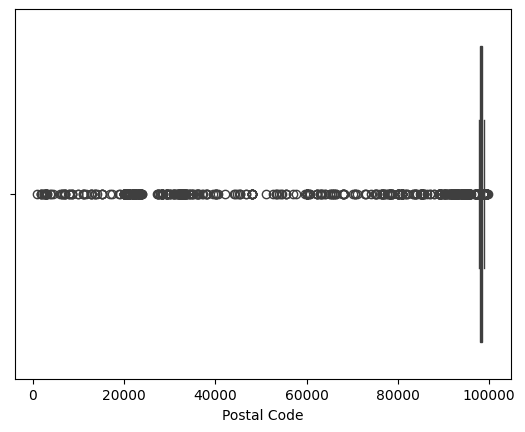

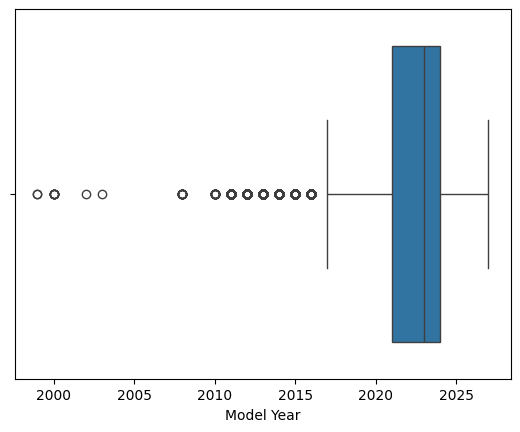

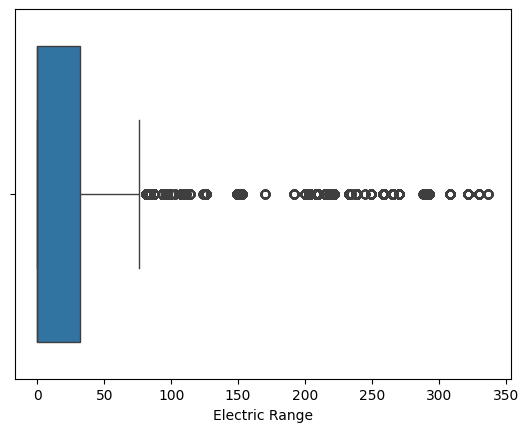

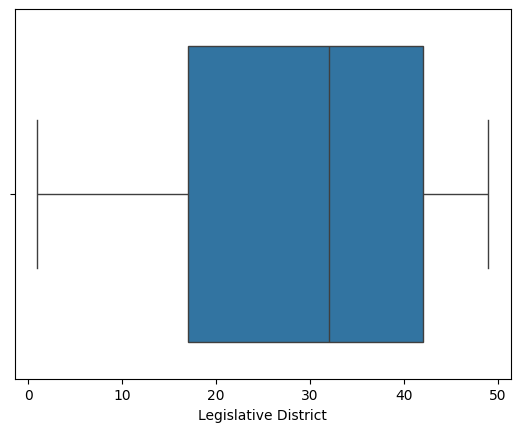

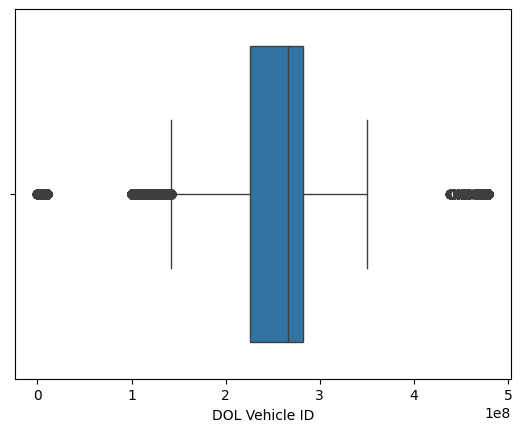

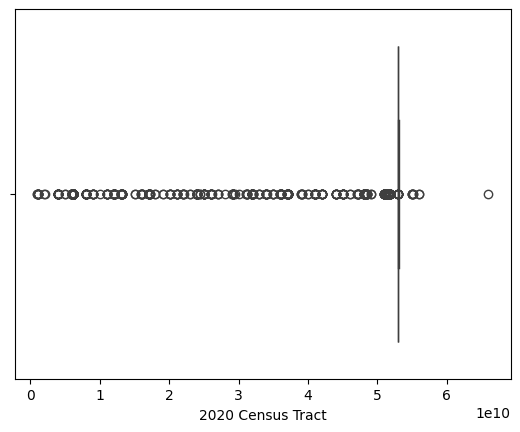

In [53]:
#outlier detection
for col in EV_df.select_dtypes(include="number"):
    sns.boxplot(x=EV_df[col])
    plt.show()

In [54]:
for col in EV_df.select_dtypes(include="number"):
    Q1 = EV_df[col].quantile(0.25)
    Q3 = EV_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = EV_df[(EV_df[col] < lower) | (EV_df[col] > upper)]
    print(col, ":", len(outliers))

Postal Code : 20120
Model Year : 18365
Electric Range : 43094
Legislative District : 0
DOL Vehicle ID : 24162
2020 Census Tract : 739


In [55]:
#outlier removal using iqr method
for col in EV_df.select_dtypes(include="number"):
    Q1 = EV_df[col].quantile(0.25)
    Q3 = EV_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    EV_df = EV_df[(EV_df[col] >= lower) & (EV_df[col] <= upper)]
    EV_df.head()

##UNIVARIATE ANALYSIS :used to clean data, catch anomalies, and determine if features require scaling or transformation prior to modeling

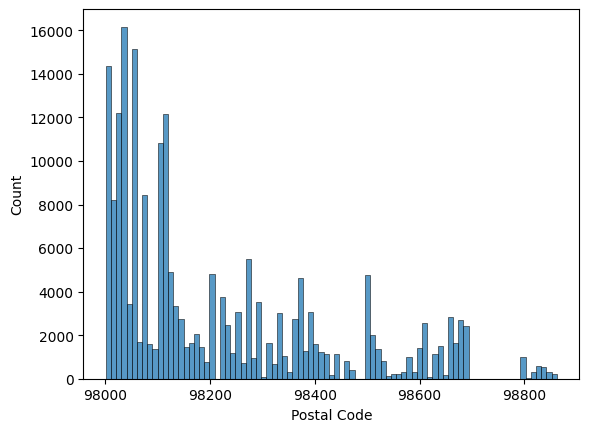

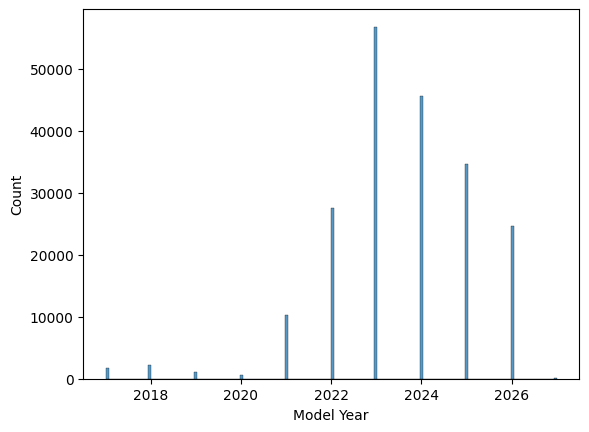

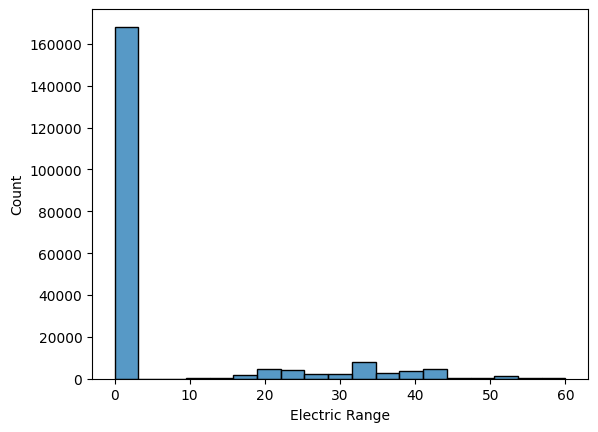

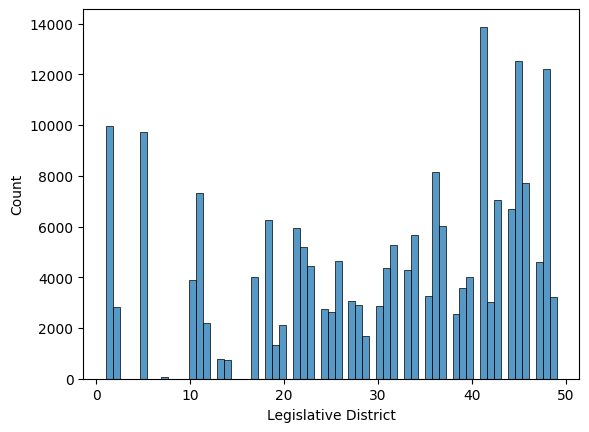

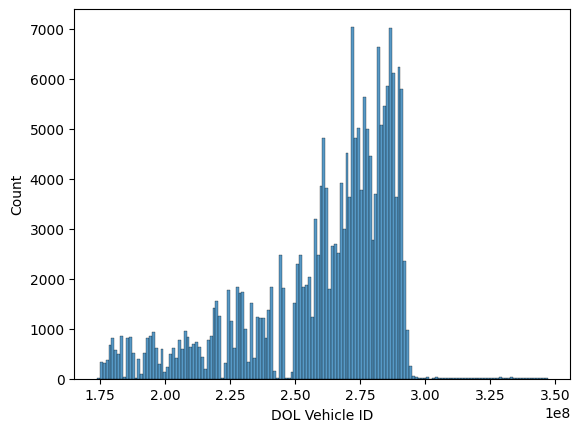

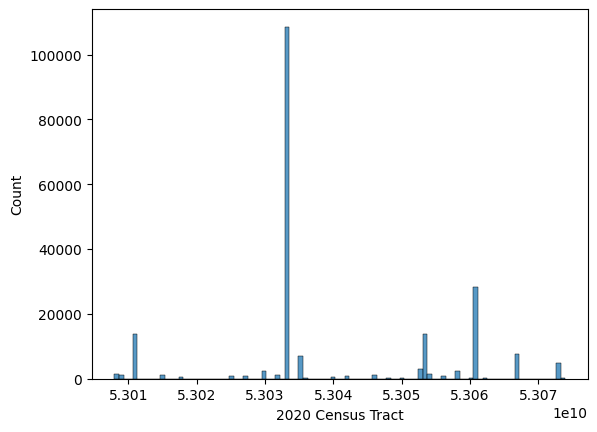

In [56]:
for cols in EV_df.select_dtypes(include="number"):
  sns.histplot(EV_df[cols])
  plt.show()

###Box plot

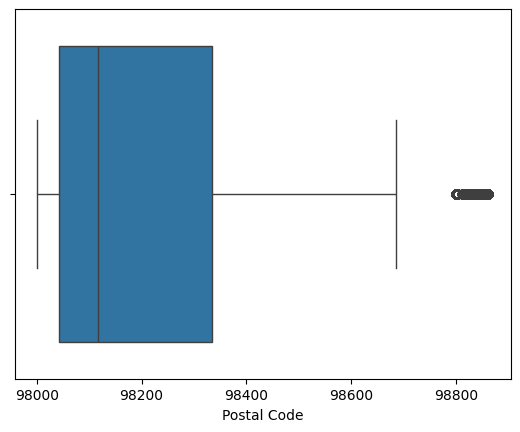

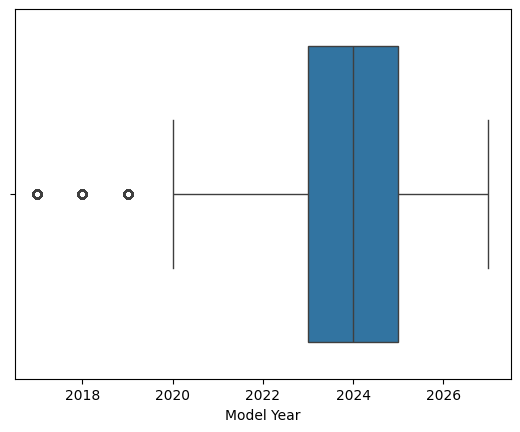

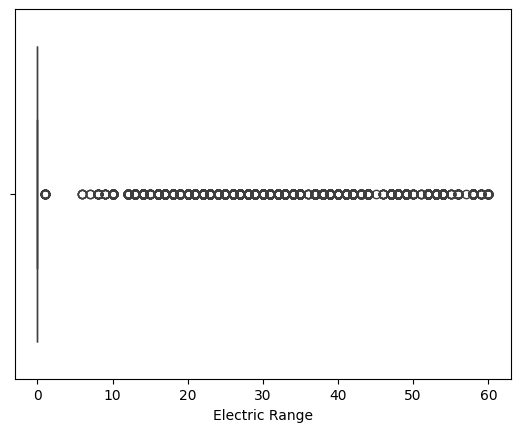

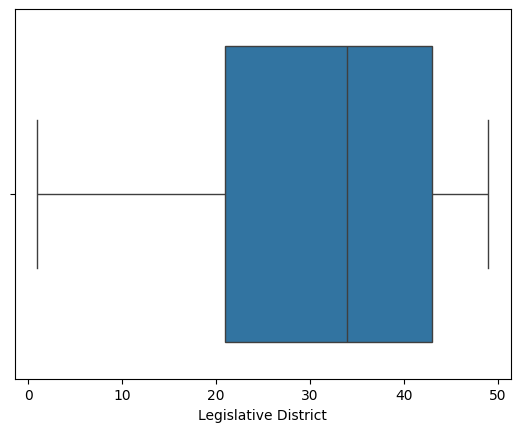

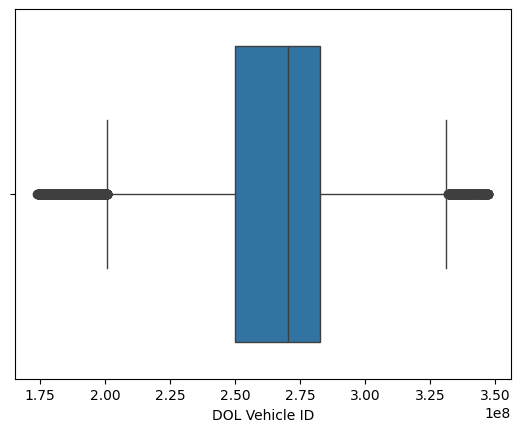

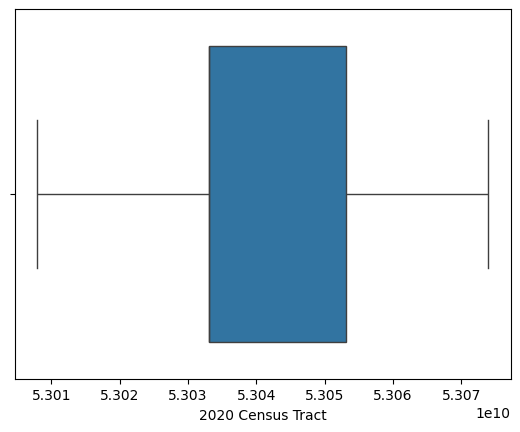

In [57]:
for col in EV_df.select_dtypes(include="number"):
    sns.boxplot(x=EV_df[col])
    plt.show()

##CORRELATION MATRIX

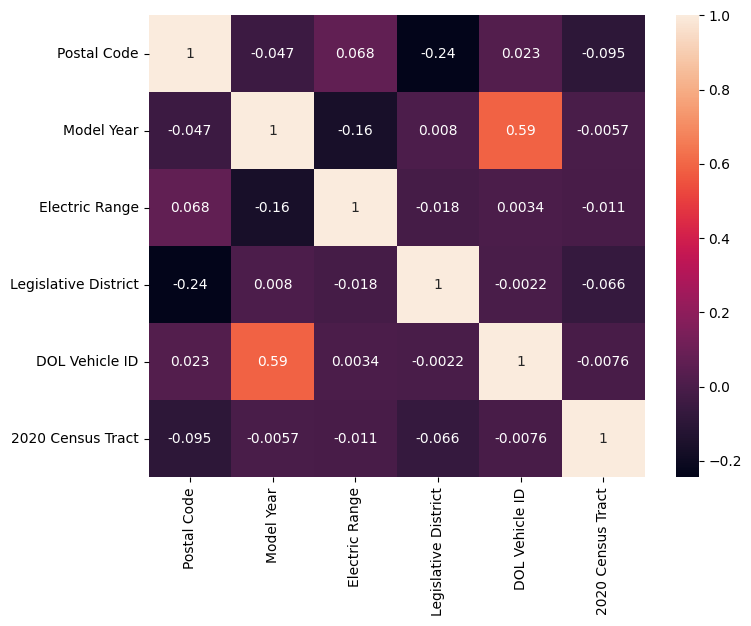

In [58]:
plt.figure(figsize=(8,6))
sns.heatmap(EV_df.select_dtypes(include="number").corr(), annot=True)
plt.show()

# Data Transformation

## Scaling

## Encoding

# Data Splitting

# Model Building